# Strategy Performance Analysis

This notebook evaluates the performance of the statistical arbitrage strategy.

Steps performed:

1. Load portfolio returns from multi-pair backtest
2. Compute portfolio equity curve
3. Compare strategy performance with NIFTY50 benchmark
4. Calculate rolling Sharpe ratio
5. Compute performance metrics (Return, Volatility, Sharpe, Drawdown)
6. Analyze profit contribution from trading pairs
7. Identify top performing pairs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf


In [2]:
portfolio_returns = pd.read_csv("../data/processed/portfolio_returns.csv",
                                index_col=0,
                                parse_dates=True)

portfolio_returns = portfolio_returns.squeeze()


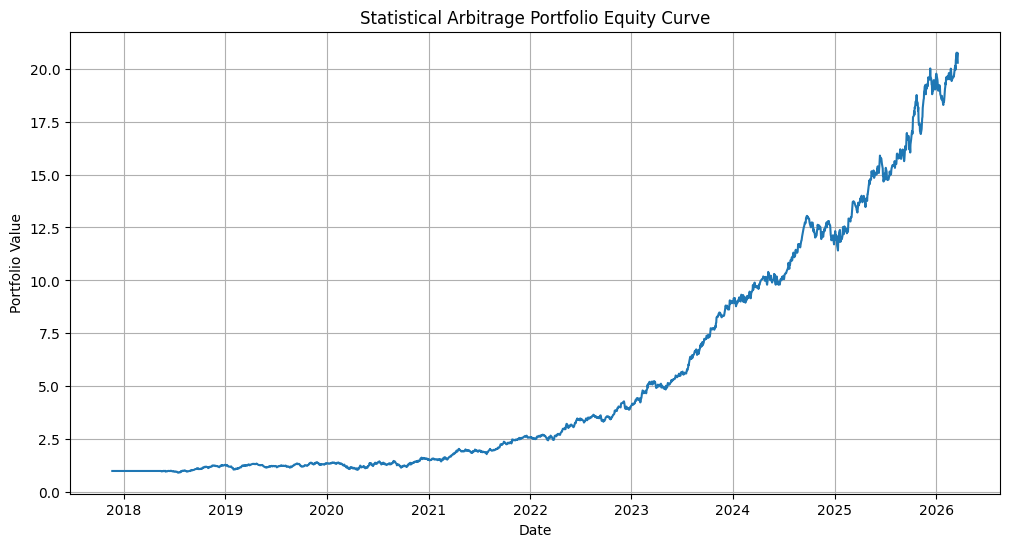

In [3]:
cumulative_returns = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12,6))
plt.plot(cumulative_returns)

plt.title("Statistical Arbitrage Portfolio Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)

plt.savefig("../reports/equity_curve.png", dpi=300)
plt.show()


In [4]:
strategy_returns=portfolio_returns.copy()
# Download NIFTY first (FIX)
nifty = yf.download("^NSEI",
                    start=strategy_returns.index.min(),
                    end=strategy_returns.index.max())

# Ensure Series
if isinstance(strategy_returns, pd.DataFrame):
    strategy_returns = strategy_returns.squeeze()

nifty_returns = nifty["Close"].pct_change().squeeze()


# Drop NaNs again after conversion
strategy_returns = strategy_returns.dropna()
nifty_returns = nifty_returns.dropna()

# Align again (important)
common_index = strategy_returns.index.intersection(nifty_returns.index)
strategy_returns = strategy_returns.loc[common_index]
nifty_returns = nifty_returns.loc[common_index]

# Correlation
corr = strategy_returns.corr(nifty_returns)
print("Correlation with NIFTY:", corr)

nifty_curve = (1 + nifty_returns).cumprod()



[*********************100%***********************]  1 of 1 completed

Correlation with NIFTY: 0.18825917858651428


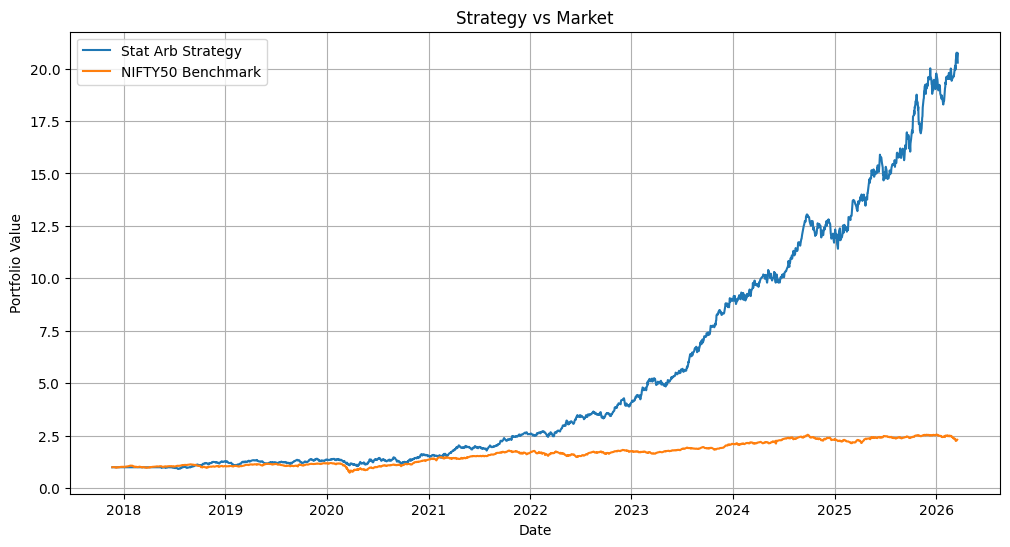

In [5]:
plt.figure(figsize=(12,6))

plt.plot(cumulative_returns, label="Stat Arb Strategy")
plt.plot(nifty_curve, label="NIFTY50 Benchmark")

plt.title("Strategy vs Market")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.grid(True)
plt.savefig("../reports/strategy_vs_nifty.png", dpi=300)
plt.show()


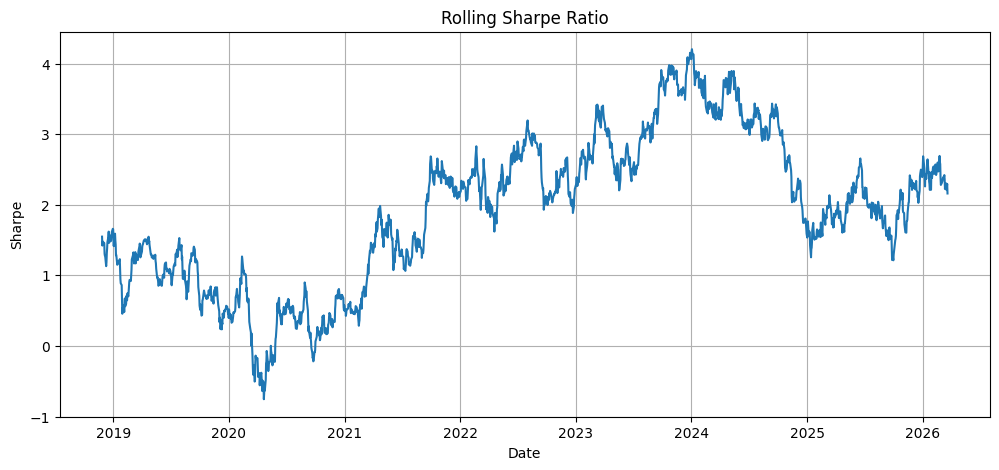

In [6]:
rolling_sharpe = (
    portfolio_returns.rolling(252).mean() /
    portfolio_returns.rolling(252).std()
)*np.sqrt(252)

plt.figure(figsize=(12,5))
plt.plot(rolling_sharpe)

plt.title("Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe")

plt.grid(True)
plt.savefig("../reports/rolling_sharpe_ratio.png", dpi=300)
plt.show()


In [7]:
total_return = cumulative_returns.iloc[-1] - 1

annual_return = portfolio_returns.mean() * 252
volatility = portfolio_returns.std() * np.sqrt(252)

risk_free_rate = 0.05 / 252

excess_returns = portfolio_returns - risk_free_rate
if excess_returns.std()!=0:

 sharpe = np.sqrt(252) * excess_returns.mean() / excess_returns.std()
else:
  sharpe=0

downside_returns = portfolio_returns[portfolio_returns < 0]
downside_std = downside_returns.std()

if downside_std != 0:
    sortino = np.sqrt(252) * portfolio_returns.mean() / downside_std
else:
    sortino = 0
drawdown = cumulative_returns / cumulative_returns.cummax() - 1
max_dd = drawdown.min()

calmar = annual_return / abs(max_dd)

metrics = pd.DataFrame({
    "Total Return":[total_return],
    "Annual Return":[annual_return],
    "Volatility":[volatility],
    "Sharpe":[sharpe],
    "Sortino":[sortino],
    "Max Drawdown":[max_dd],
    "Calmar":[calmar]
})

metrics


,Total Return,Annual Return,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
0,19.279133,0.395012,0.230789,1.494924,2.740893,-0.253309,1.55941


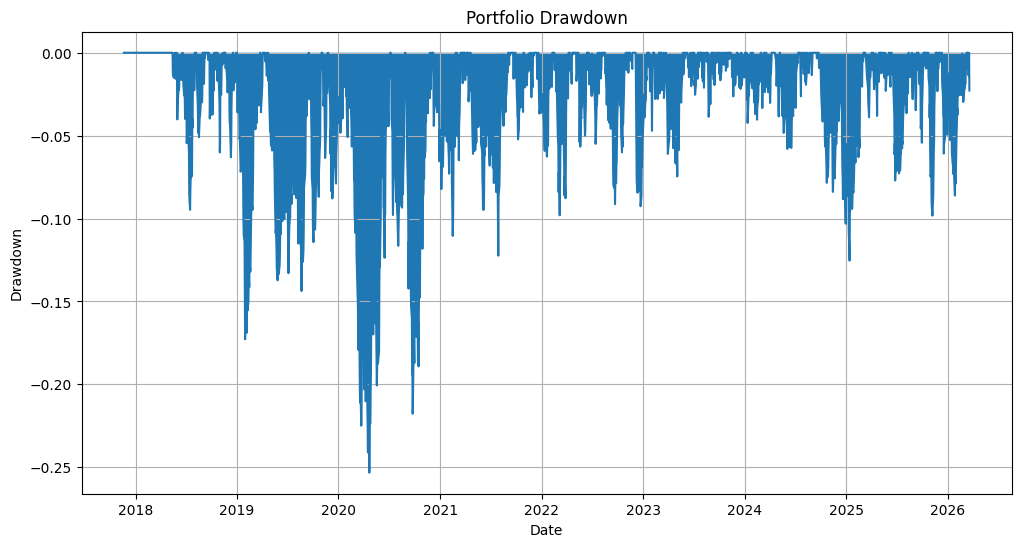

In [8]:
plt.figure(figsize=(12,6))

plt.plot(drawdown)
plt.fill_between(drawdown.index, drawdown, 0)

plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.grid(True)
plt.savefig("../reports/portfolio_drawdown.png", dpi=300)
plt.show()

In [9]:
metrics.to_csv("../data/processed/strategy_metrics.csv", index=False)

print("Strategy metrics saved successfully")

Strategy metrics saved successfully


In [10]:
pair_performance = pd.read_csv("../data/processed/pair_performance.csv",
                               index_col=0)


<Figure size 1200x600 with 0 Axes>

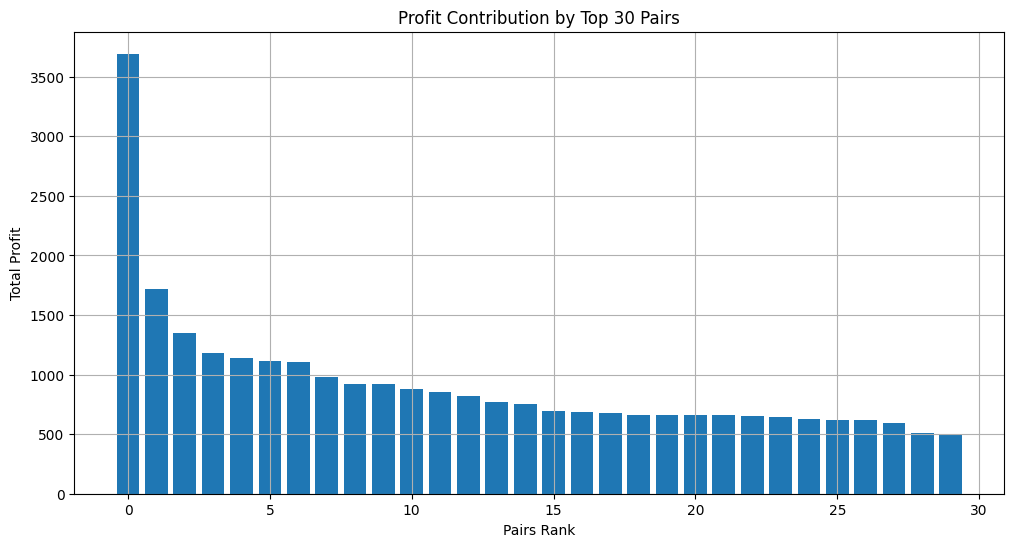

In [11]:
pairs_list = pair_performance.index
profits = pair_performance["profit"]

plt.figure(figsize=(12,6))
sorted_pairs = pair_performance.sort_values("profit", ascending=False)

top_pairs_plot = sorted_pairs.head(30)

plt.figure(figsize=(12,6))

plt.bar(range(len(top_pairs_plot)), top_pairs_plot["profit"])

plt.title("Profit Contribution by Top 30 Pairs")
plt.xlabel("Pairs Rank")
plt.ylabel("Total Profit")

plt.grid(True)
plt.savefig("../reports/pair_profit_distribution.png", dpi=300)
plt.show()



In [12]:
top_pairs = pair_performance.sort_values("profit", ascending=False)

print("Top 5 Pairs:")
print(top_pairs.head())


Top 5 Pairs:
                                         profit
pair                                           
('APOLLOHOSP.NS', 'ULTRACEMCO.NS')  3693.901855
('EICHERMOT.NS', 'MARUTI.NS')       1715.404297
('BRITANNIA.NS', 'LT.NS')           1345.148438
('BRITANNIA.NS', 'SUNPHARMA.NS')    1183.976929
('BRITANNIA.NS', 'ULTRACEMCO.NS')   1139.236816


### Strategy Performance Summary

This notebook evaluates the performance of the statistical arbitrage pairs trading strategy.

**Key observations**

- The strategy generated strong cumulative returns.
- Rolling Sharpe ratio indicates stable risk-adjusted performance.
- Portfolio drawdowns remained within acceptable limits.
- Several cointegrated pairs produced consistent trading profits.

**Conclusion**

The results show that cointegration-based pairs trading can effectively exploit mean-reversion opportunities in the market.